# Problem Set 04

Lukas Vrouwenvelder

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Q1

In [3]:
X = np.array([1, 1.75, 2, 3, 3.25, 4])
n = len(X)
sd = X.std(ddof=1)           # ddof=1 for sample SD (divides by n-1)
h_u = 1.84 * sd * n**(-0.2)

print("SD:", sd)
print("n^(-0.2):", n**(-0.2))
print("h_u:", h_u)

SD: 1.1067971810589328
n^(-0.2): 0.6988271187715792
h_u: 1.4231661885912126


In [9]:
df = pd.DataFrame({'x': X})
df['lowRange']  = df['x'] - h_u
df['highRange'] = df['x'] + h_u
df

,x,lowRange,highRange
0,1.00,-0.423166,2.423166
1,1.75,0.326834,3.173166
2,2.00,0.576834,3.423166
3,3.00,1.576834,4.423166
4,3.25,1.826834,4.673166
5,4.00,2.576834,5.423166


## Q3

In [ ]:
X_Values = [5, 7, 7, 8, 10]
x_grid = [6.0, 6.5, 7.0, 8.0, 8.5]

#### Q3a

In [ ]:
def uniform_kde(x_grid, X, h):
    X = np.array(X)
    x_grid = np.array(x_grid)
    I = np.abs(x_grid[:, None] - X[None, :]) < h
    n = len(X)
    f_hat = np.sum(I, axis=1) / (2 * n * h)
    return f_hat

print(uniform_kde(x_grid, X_Values, h=1.5))

[0.2        0.13333333 0.2        0.2        0.06666667]


#### Q3b

In [11]:
def gaussian_kde(x_grid, X, h):
    X = np.array(X)
    x_grid = np.array(x_grid)
    gauss = lambda z: np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)
    n = len(X)
    K = gauss((x_grid[:, None] - X[None, :]) / h) / h
    f_hat = K.mean(axis=1)
    return f_hat

print(gaussian_kde(x_grid, X_Values, h=1.5))

[0.15116668 0.16865731 0.17804448 0.16744524 0.15060231]


## Q4

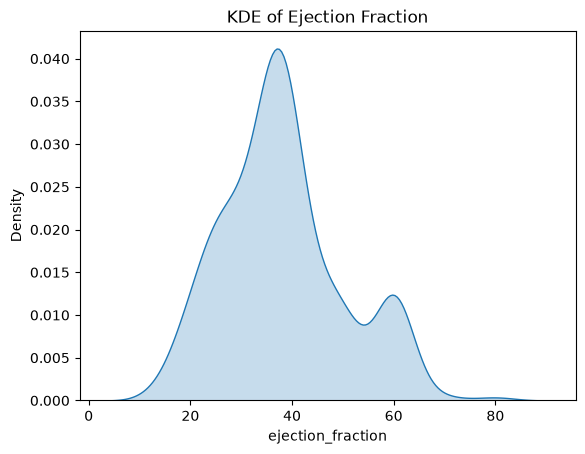

In [14]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

sns.kdeplot(data=df, x='ejection_fraction', fill=True)
plt.title('KDE of Ejection Fraction')
plt.show()

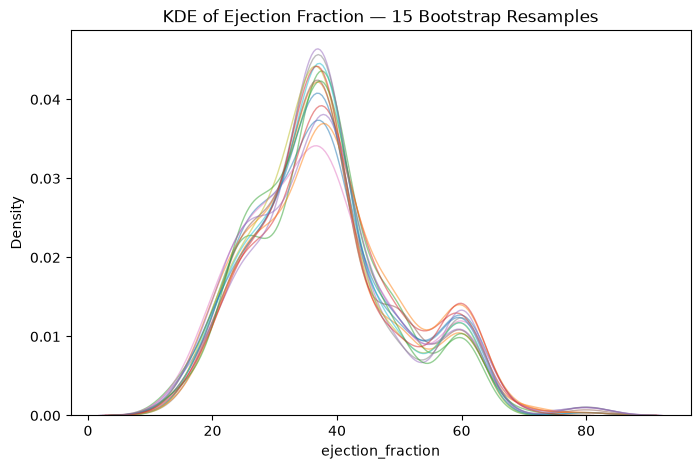

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(15):
    resample = df.sample(frac=1.0, replace=True)
    sns.kdeplot(data=resample, x='ejection_fraction', ax=ax, alpha=0.5, linewidth=1)

plt.title('KDE of Ejection Fraction — 15 Bootstrap Resamples')
plt.show()